In [1]:
import xarray as xr

# Open the NetCDF file
ds = xr.open_dataset("/Volumes/Expansion/ERA-5_Data/Global_Data/Latent_and_Sensible_Heat/latent_sensibl_1980.nc")

# Print summary of the dataset
print(ds)

<xarray.Dataset>
Dimensions:  (time: 366, lon: 1440, lat: 481)
Coordinates:
  * time     (time) datetime64[ns] 1980-01-01T14:00:00 ... 1980-12-31T14:00:00
  * lon      (lon) float64 -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
  * lat      (lat) float64 60.0 59.75 59.5 59.25 ... -59.25 -59.5 -59.75 -60.0
Data variables:
    var147   (time, lat, lon) float32 ...
    var146   (time, lat, lon) float32 ...
Attributes:
    CDI:          Climate Data Interface version 2.5.3 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Wed Sep 24 16:02:59 2025: cdo -f nc splityear data.grib lat...
    CDO:          Climate Data Operators version 2.5.3 (https://mpimet.mpg.de...


In [2]:
import xarray as xr

ds = xr.open_dataset("/Volumes/Expansion/ERA-5_Data/Global_Data/Latent_and_Sensible_Heat/latent_sensibl_1980.nc")

# Extract variables
v147 = ds["var147"]
v146 = ds["var146"]

# Print basic info
print("var147:")
print(v147)
print("dims:", v147.dims)
print("shape:", v147.shape)
print("dtype:", v147.dtype)
print()

print("var146:")
print(v146)
print("dims:", v146.dims)
print("shape:", v146.shape)
print("dtype:", v146.dtype)
print()

# Dataset coords
print("time shape:", ds["time"].shape)
print("lat shape:", ds["lat"].shape)
print("lon shape:", ds["lon"].shape)

var147:
<xarray.DataArray 'var147' (time: 366, lat: 481, lon: 1440)>
[253506240 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 1980-01-01T14:00:00 ... 1980-12-31T14:00:00
  * lon      (lon) float64 -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
  * lat      (lat) float64 60.0 59.75 59.5 59.25 ... -59.25 -59.5 -59.75 -60.0
Attributes:
    table:    128
dims: ('time', 'lat', 'lon')
shape: (366, 481, 1440)
dtype: float32

var146:
<xarray.DataArray 'var146' (time: 366, lat: 481, lon: 1440)>
[253506240 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 1980-01-01T14:00:00 ... 1980-12-31T14:00:00
  * lon      (lon) float64 -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
  * lat      (lat) float64 60.0 59.75 59.5 59.25 ... -59.25 -59.5 -59.75 -60.0
Attributes:
    table:    128
dims: ('time', 'lat', 'lon')
shape: (366, 481, 1440)
dtype: float32

time shape: (366,)
lat shape: (481,)
lon shape: (1440,)


In [3]:
print(v147.dims, v147.shape)
print(v146.dims, v146.shape)

('time', 'lat', 'lon') (366, 481, 1440)
('time', 'lat', 'lon') (366, 481, 1440)


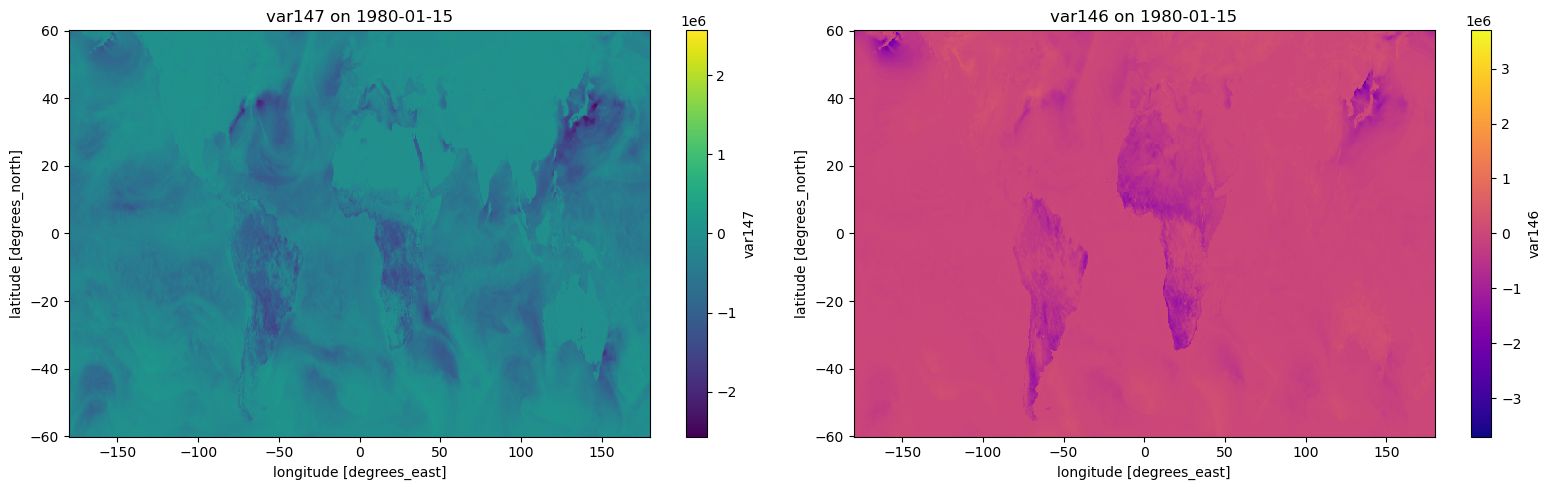

In [4]:
import matplotlib.pyplot as plt

date_sel = "1980-01-15"

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

v147.sel(time=date_sel).plot(ax=axes[0], x="lon", y="lat", cmap="viridis")
axes[0].set_title(f"var147 on {date_sel}")

v146.sel(time=date_sel).plot(ax=axes[1], x="lon", y="lat", cmap="plasma")
axes[1].set_title(f"var146 on {date_sel}")

plt.tight_layout()
plt.show()

Regional var147 time series shape: (366,)
Regional var146 time series shape: (366,)


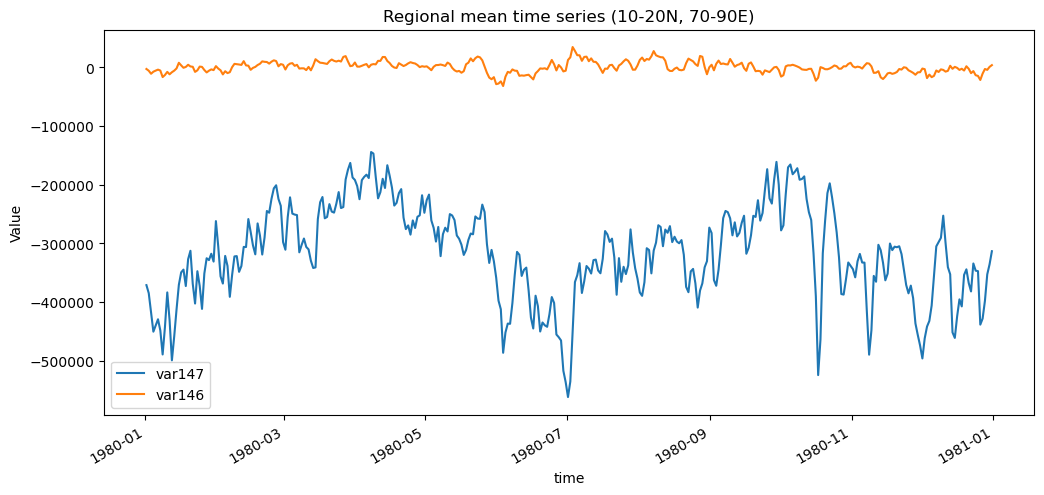

In [3]:
import xarray as xr
import matplotlib.pyplot as plt

ds = xr.open_dataset("/Volumes/Expansion/ERA-5_Data/Global_Data/Latent_and_Sensible_Heat/latent_sensibl_1980.nc").sortby("lat")

v147 = ds["var147"]
v146 = ds["var146"]

# Define region
lat_min, lat_max = 10, 20
lon_min, lon_max = 70, 90

# Subset region
reg147 = v147.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
reg146 = v146.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

# Regional mean time series
ts147 = reg147.mean(dim=("lat", "lon"))
ts146 = reg146.mean(dim=("lat", "lon"))

print("Regional var147 time series shape:", ts147.shape)
print("Regional var146 time series shape:", ts146.shape)

# Plot
plt.figure(figsize=(12, 5))
ts147.plot(label="var147")
ts146.plot(label="var146")
plt.legend()
plt.title(f"Regional mean time series ({lat_min}-{lat_max}N, {lon_min}-{lon_max}E)")
plt.ylabel("Value")
plt.show()

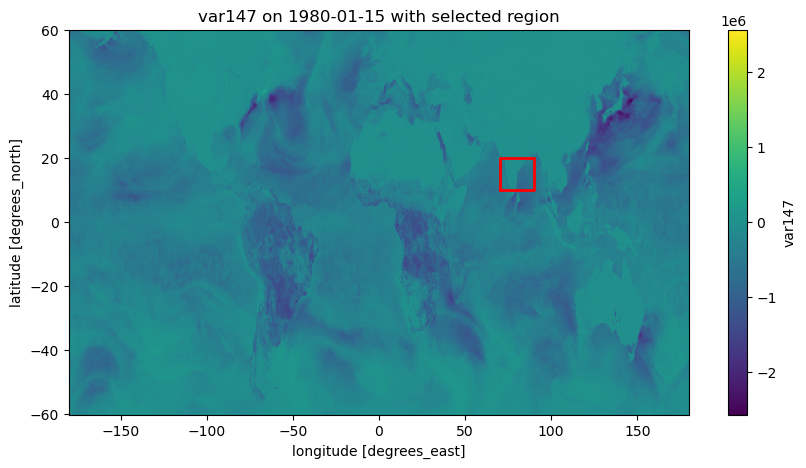

In [8]:
import matplotlib.pyplot as plt

date_sel = "1980-01-15"

plt.figure(figsize=(10, 5))
v147.sel(time=date_sel).plot(x="lon", y="lat", cmap="viridis")

# Draw box
plt.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    color="red", linewidth=2
)

plt.title(f"var147 on {date_sel} with selected region")
plt.show()

In [13]:
print(v147.attrs)
print(v146.attrs)

{'table': 128}
{'table': 128}


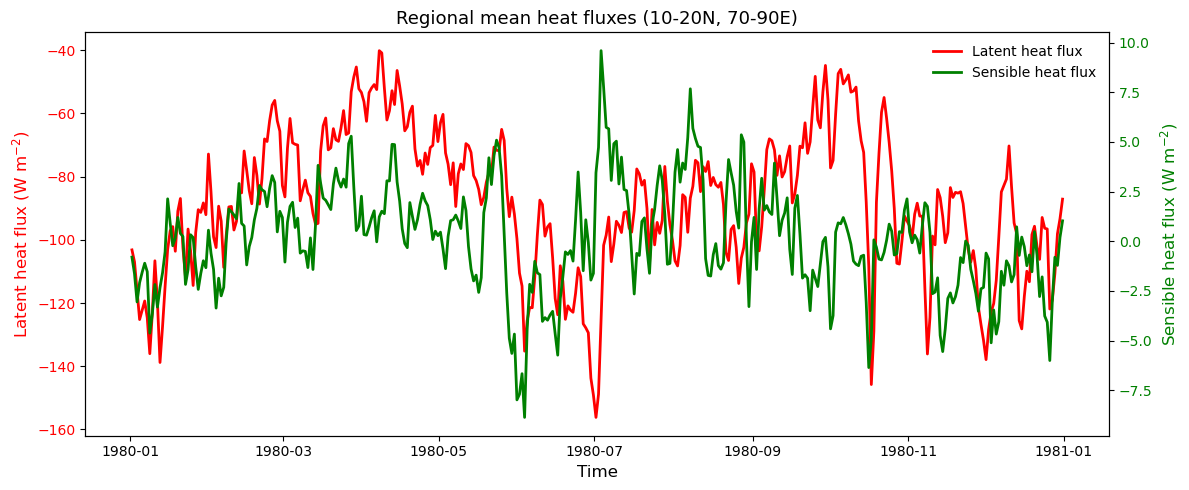

In [16]:
import xarray as xr
import matplotlib.pyplot as plt

ds = xr.open_dataset("/Volumes/Expansion/ERA-5_Data/Global_Data/Latent_and_Sensible_Heat/latent_sensibl_1980.nc").sortby("lat")

# ECMWF param mapping
v146 = ds["var146"]   # Surface sensible heat flux
v147 = ds["var147"]   # Surface latent heat flux

# Optional: convert from J m^-2 per hour to W m^-2
v146 = v146 / 3600.0
v147 = v147 / 3600.0

lat_min, lat_max = 10, 20
lon_min, lon_max = 70, 90

reg146 = v146.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
reg147 = v147.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

ts146 = reg146.mean(dim=("lat", "lon"))
ts147 = reg147.mean(dim=("lat", "lon"))

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

line1 = ax1.plot(ts147["time"], ts147.values, label="Latent heat flux", linewidth=2, color="red")
line2 = ax2.plot(ts146["time"], ts146.values, label="Sensible heat flux", linewidth=2, color="green")

ax1.set_xlabel("Time", fontsize=12)
ax1.set_ylabel("Latent heat flux (W m$^{-2}$)", fontsize=12, color="red")
ax2.set_ylabel("Sensible heat flux (W m$^{-2}$)", fontsize=12, color="green")

ax1.tick_params(axis="y", labelcolor="red")
ax2.tick_params(axis="y", labelcolor="green")

ax1.set_title(f"Regional mean heat fluxes ({lat_min}-{lat_max}N, {lon_min}-{lon_max}E)", fontsize=13)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right", frameon=False)

plt.tight_layout()
plt.show()

In [17]:
import numpy as np
import xarray as xr
from scipy.interpolate import RegularGridInterpolator

infile           = "/Volumes/Expansion/ERA-5_Data/Global_Data/Latent_and_Sensible_Heat/latent_sensibl_1980.nc"
target_xy        = np.load("/Volumes/Expansion/Soil_Hot_DRought/Soil_Locations.npz")
target_xy        = target_xy['arr_0']
print(target_xy.shape)


target_lon = target_xy[:, 0]
target_lat = target_xy[:, 1]
#target_lon = np.where(target_lon > 180, target_lon - 360, target_lon)
target_points = np.column_stack([target_lat, target_lon])

ds = xr.open_dataset(infile)
if np.any(np.diff(ds["lat"].values) < 0):
    ds = ds.sortby("lat")

lat = ds["lat"].values
lon = ds["lon"].values

for t in range(ds.sizes["time"]):
    field = ds["var147"].isel(time=t).values
    f = RegularGridInterpolator((lat, lon), field, bounds_error=False, fill_value=np.nan)
    vals = f(target_points)
    print(t, vals.shape)

(44531, 2)
0 (44531,)
1 (44531,)
2 (44531,)
3 (44531,)
4 (44531,)
5 (44531,)
6 (44531,)
7 (44531,)
8 (44531,)
9 (44531,)
10 (44531,)
11 (44531,)
12 (44531,)
13 (44531,)
14 (44531,)
15 (44531,)
16 (44531,)
17 (44531,)
18 (44531,)
19 (44531,)
20 (44531,)
21 (44531,)
22 (44531,)
23 (44531,)
24 (44531,)
25 (44531,)
26 (44531,)
27 (44531,)
28 (44531,)
29 (44531,)
30 (44531,)
31 (44531,)
32 (44531,)
33 (44531,)
34 (44531,)
35 (44531,)
36 (44531,)
37 (44531,)
38 (44531,)
39 (44531,)
40 (44531,)
41 (44531,)
42 (44531,)
43 (44531,)
44 (44531,)
45 (44531,)
46 (44531,)
47 (44531,)
48 (44531,)
49 (44531,)
50 (44531,)
51 (44531,)
52 (44531,)
53 (44531,)
54 (44531,)
55 (44531,)
56 (44531,)
57 (44531,)
58 (44531,)
59 (44531,)
60 (44531,)
61 (44531,)
62 (44531,)
63 (44531,)
64 (44531,)
65 (44531,)
66 (44531,)
67 (44531,)
68 (44531,)
69 (44531,)
70 (44531,)
71 (44531,)
72 (44531,)
73 (44531,)
74 (44531,)
75 (44531,)
76 (44531,)
77 (44531,)
78 (44531,)
79 (44531,)
80 (44531,)
81 (44531,)
82 (44531,)
83 

In [28]:
import os
import numpy as np
import xarray as xr
from scipy.interpolate import RegularGridInterpolator


def regrid_nc_to_points(
    infile,
    outfile,
    target_lonlat,
    var_names=None,
    method="linear",
    time_chunk=1,
    convert_lon_to_180=False,
    compression_level=4,
):
    """
    Regrid variables from a regular lat-lon NetCDF file to an irregular set of points.

    Parameters
    ----------
    infile : str
        Path to input NetCDF file.
    outfile : str
        Path to output NetCDF file.
    target_lonlat : np.ndarray
        Array of shape (npoint, 2), where:
            target_lonlat[:, 0] = lon
            target_lonlat[:, 1] = lat
    var_names : list of str, optional
        Variables to interpolate. If None, all data variables are used.
    method : str, optional
        Interpolation method: "linear" or "nearest".
    time_chunk : int, optional
        Number of time steps to process at once.
    convert_lon_to_180 : bool, optional
        If True, converts target longitudes from 0..360 to -180..180 when needed.
    compression_level : int, optional
        zlib compression level for output NetCDF.

    Returns
    -------
    None
    """

    if method not in ("linear", "nearest"):
        raise ValueError("method must be 'linear' or 'nearest'")

    if target_lonlat.ndim != 2 or target_lonlat.shape[1] != 2:
        raise ValueError("target_lonlat must have shape (npoint, 2) with columns [lon, lat]")

    # -------------------------
    # Open input lazily
    # -------------------------
    ds = xr.open_dataset(infile)

    # Ensure required coordinates exist
    for coord in ["time", "lat", "lon"]:
        if coord not in ds.coords:
            raise ValueError(f"Missing required coordinate: {coord}")

    # Choose variables
    if var_names is None:
        var_names = list(ds.data_vars)

    for v in var_names:
        if v not in ds.data_vars:
            raise ValueError(f"Variable '{v}' not found in dataset")

    # Sort latitude ascending for RegularGridInterpolator
    if np.any(np.diff(ds["lat"].values) < 0):
        ds = ds.sortby("lat")

    lat = ds["lat"].values
    lon = ds["lon"].values
    time = ds["time"].values

    ntime = ds.sizes["time"]
    npoint = target_lonlat.shape[0]

    # -------------------------
    # Prepare target points
    # -------------------------
    target_lon = target_lonlat[:, 0].astype(np.float64).copy()
    target_lat = target_lonlat[:, 1].astype(np.float64).copy()

    # Convert target longitudes if needed
    if convert_lon_to_180:
        if lon.min() >= -180 and lon.max() <= 180:
            target_lon = np.where(target_lon > 180, target_lon - 360, target_lon)

    # Interpolator expects points ordered as (lat, lon)
    target_points = np.column_stack([target_lat, target_lon])

    # -------------------------
    # Pre-allocate output arrays
    # -------------------------
    out_data = {
        v: np.full((ntime, npoint), np.nan, dtype=np.float32)
        for v in var_names
    }

    # -------------------------
    # Process in chunks over time
    # -------------------------
    for t0 in range(0, ntime, time_chunk):
        t1 = min(t0 + time_chunk, ntime)
        print(f"Processing time steps {t0} to {t1 - 1} / {ntime - 1}")

        for v in var_names:
            arr_chunk = ds[v].isel(time=slice(t0, t1)).values  # shape (chunk, lat, lon)

            for k in range(arr_chunk.shape[0]):
                field = arr_chunk[k, :, :]  # shape (lat, lon)

                interp_func = RegularGridInterpolator(
                    (lat, lon),
                    field,
                    method=method,
                    bounds_error=False,
                    fill_value=np.nan,
                )

                out_data[v][t0 + k, :] = interp_func(target_points).astype(np.float32)

    # -------------------------
    # Build output dataset
    # -------------------------
    ds_out = xr.Dataset(
        data_vars={
            v: (("time", "point"), out_data[v], ds[v].attrs)
            for v in var_names
        },
        coords={
            "time": time,
            "point": np.arange(npoint, dtype=np.int32),
            "lon": ("point", target_lon),
            "lat": ("point", target_lat),
        },
        attrs=ds.attrs,
    )

    # Add helpful metadata
    ds_out["lon"].attrs = {"long_name": "longitude", "units": "degrees_east"}
    ds_out["lat"].attrs = {"long_name": "latitude", "units": "degrees_north"}

    # -------------------------
    # Encoding / compression
    # -------------------------
    encoding = {
        v: {
            "zlib": True,
            "complevel": compression_level,
            "dtype": "float32",
            "chunksizes": (min(time_chunk, ntime), npoint),
        }
        for v in var_names
    }

    # Remove old file if it exists
    if os.path.exists(outfile):
        os.remove(outfile)

    
    ds_out.to_netcdf(outfile, format="NETCDF4", encoding=encoding)
    print(f"Saved regridded file to: {outfile}")

In [31]:
import numpy as np

# target_lonlat must be shape (44531, 2)
# col 0 = lon, col 1 = lat
target_lonlat        = np.load("/Volumes/Expansion/Soil_Hot_DRought/Soil_Locations.npz")
target_lonlat        = target_lonlat['arr_0']

regrid_nc_to_points(
    infile="/Volumes/Expansion/ERA-5_Data/Global_Data/Latent_and_Sensible_Heat/latent_sensibl_1983.nc",
    outfile="/Volumes/Expansion/ERA-5_Data/Global_Data/Latent_Sensible_Heat_Soil_HD/latent_sensible_1983_cpc.nc",
    target_lonlat=target_lonlat,
    var_names=["var146", "var147"],
    method="linear",      # or "nearest"
    time_chunk=5,         # adjust depending on memory
    convert_lon_to_180=True,
    compression_level=4,
)

Processing time steps 0 to 4 / 364
Processing time steps 5 to 9 / 364
Processing time steps 10 to 14 / 364
Processing time steps 15 to 19 / 364
Processing time steps 20 to 24 / 364
Processing time steps 25 to 29 / 364
Processing time steps 30 to 34 / 364
Processing time steps 35 to 39 / 364
Processing time steps 40 to 44 / 364
Processing time steps 45 to 49 / 364
Processing time steps 50 to 54 / 364
Processing time steps 55 to 59 / 364
Processing time steps 60 to 64 / 364
Processing time steps 65 to 69 / 364
Processing time steps 70 to 74 / 364
Processing time steps 75 to 79 / 364
Processing time steps 80 to 84 / 364
Processing time steps 85 to 89 / 364
Processing time steps 90 to 94 / 364
Processing time steps 95 to 99 / 364
Processing time steps 100 to 104 / 364
Processing time steps 105 to 109 / 364
Processing time steps 110 to 114 / 364
Processing time steps 115 to 119 / 364
Processing time steps 120 to 124 / 364
Processing time steps 125 to 129 / 364
Processing time steps 130 to 1

In [32]:
import os
import numpy as np

# target_lonlat already loaded
# target_lonlat = np.load("target_lonlat.npy")

in_dir = "/Volumes/Expansion/ERA-5_Data/Global_Data/Latent_and_Sensible_Heat"
out_dir = "/Volumes/Expansion/ERA-5_Data/Global_Data/Latent_Sensible_Heat_Soil_HD"

os.makedirs(out_dir, exist_ok=True)

for year in range(1983, 2024):   # 2024 is excluded, so this runs 1983..2023
    infile = os.path.join(in_dir, f"latent_sensibl_{year}.nc")
    outfile = os.path.join(out_dir, f"latent_sensible_{year}_cpc.nc")

    if not os.path.exists(infile):
        print(f"Skipping {year}: input file not found")
        continue

    if os.path.exists(outfile):
        print(f"Skipping {year}: output already exists")
        continue

    print(f"Processing {year}...")

    regrid_nc_to_points(
        infile=infile,
        outfile=outfile,
        target_lonlat=target_lonlat,
        var_names=["var146", "var147"],
        method="linear",      # or "nearest"
        time_chunk=5,
        convert_lon_to_180=True,
        compression_level=4,
    )

    print(f"Finished {year}")

Processing 1983...
Processing time steps 0 to 4 / 364
Processing time steps 5 to 9 / 364
Processing time steps 10 to 14 / 364
Processing time steps 15 to 19 / 364
Processing time steps 20 to 24 / 364
Processing time steps 25 to 29 / 364
Processing time steps 30 to 34 / 364
Processing time steps 35 to 39 / 364
Processing time steps 40 to 44 / 364
Processing time steps 45 to 49 / 364
Processing time steps 50 to 54 / 364
Processing time steps 55 to 59 / 364
Processing time steps 60 to 64 / 364
Processing time steps 65 to 69 / 364
Processing time steps 70 to 74 / 364
Processing time steps 75 to 79 / 364
Processing time steps 80 to 84 / 364
Processing time steps 85 to 89 / 364
Processing time steps 90 to 94 / 364
Processing time steps 95 to 99 / 364
Processing time steps 100 to 104 / 364
Processing time steps 105 to 109 / 364
Processing time steps 110 to 114 / 364
Processing time steps 115 to 119 / 364
Processing time steps 120 to 124 / 364
Processing time steps 125 to 129 / 364
Processing 

In [24]:
import xarray as xr
import matplotlib.pyplot as plt

ds = xr.open_dataset("/Volumes/Expansion/ERA-5_Data/Global_Data/Latent_Sensible_Heat_Soil_HD/latent_sensible_1980_cpc.nc").sortby("lat")

print(ds)

 # ECMWF param mapping
v146 = ds["var146"]   # Surface sensible heat flux
v147 = ds["var147"]   # Surface latent heat flux

lon  = ds["lon"]
lat  = ds["lat"]       




<xarray.Dataset>
Dimensions:  (time: 366, point: 44531)
Coordinates:
  * time     (time) datetime64[ns] 1980-01-01T14:00:00 ... 1980-12-31T14:00:00
  * point    (point) int32 0 1 2 3 4 5 6 ... 44525 44526 44527 44528 44529 44530
    lon      (point) float64 ...
    lat      (point) float64 ...
Data variables:
    var146   (time, point) float32 ...
    var147   (time, point) float32 ...
Attributes:
    CDI:          Climate Data Interface version 2.5.3 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Wed Sep 24 16:02:59 2025: cdo -f nc splityear data.grib lat...
    CDO:          Climate Data Operators version 2.5.3 (https://mpimet.mpg.de...


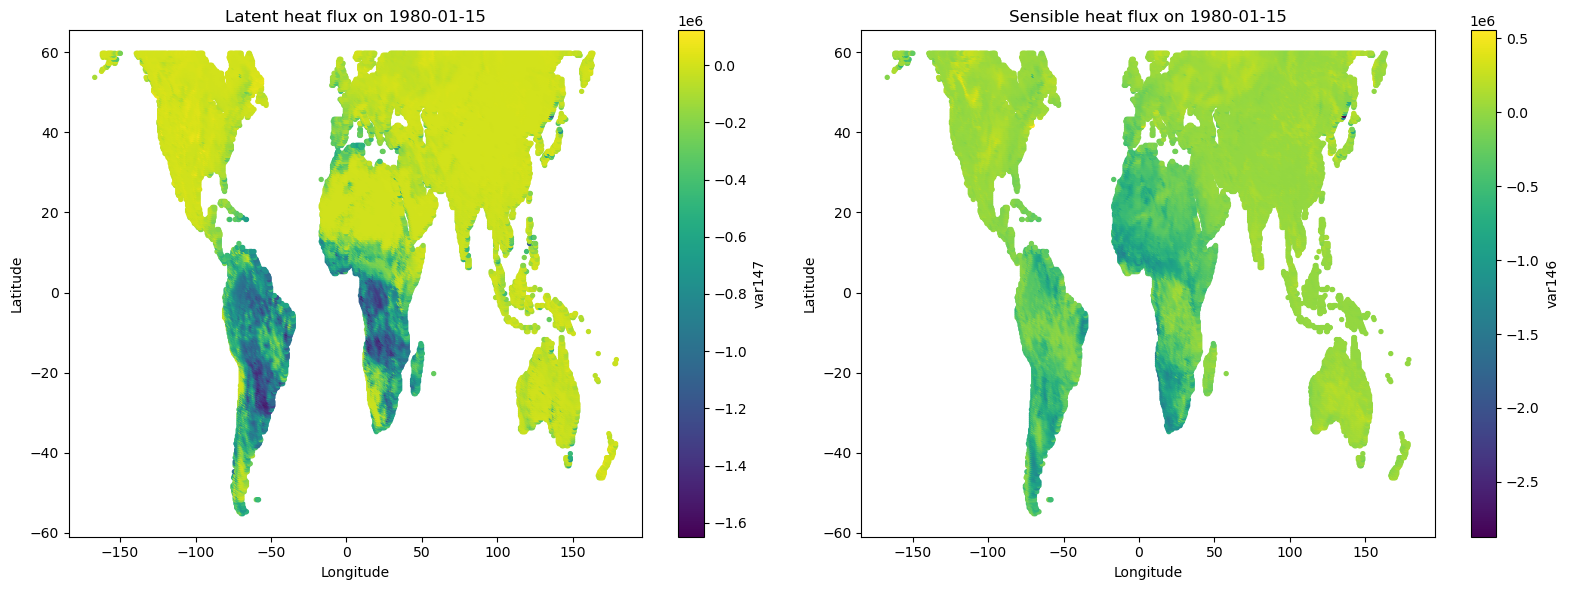

In [25]:
date_sel = "1980-01-15"

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(
    lon, lat,
    c=v147.sel(time=date_sel).values,
    s=8
)
axes[0].set_title(f"Latent heat flux on {date_sel}")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
plt.colorbar(sc1, ax=axes[0], label="var147")

sc2 = axes[1].scatter(
    lon, lat,
    c=v146.sel(time=date_sel).values,
    s=8
)
axes[1].set_title(f"Sensible heat flux on {date_sel}")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
plt.colorbar(sc2, ax=axes[1], label="var146")

plt.tight_layout()
plt.show()

In [33]:
import os
import xarray as xr
import numpy as np

folder = "/Volumes/Expansion/ERA-5_Data/Global_Data/Latent_Sensible_Heat_Soil_HD"

files = [
    os.path.join(folder, f"latent_sensible_{year}_cpc.nc")
    for year in range(1980, 2024)
]

# Open all yearly files
ds = xr.open_mfdataset(
    files,
    combine="by_coords",
    parallel=False
)

print("Before removing Feb 29:")
print(ds)

# Remove Feb 29
mask = ~((ds["time"].dt.month == 2) & (ds["time"].dt.day == 29))
ds = ds.sel(time=mask)

print("\nAfter removing Feb 29:")
print(ds)
print("Time length:", ds.sizes["time"])

# Extract coordinates
lon = ds["lon"].values
lat = ds["lat"].values

# Extract variables
v146 = ds["var146"].values   # (time, point)
v147 = ds["var147"].values   # (time, point)

print("\nShapes before transpose:")
print("lon :", lon.shape)
print("lat :", lat.shape)
print("v146:", v146.shape)
print("v147:", v147.shape)

# Optional transpose to (point, time)
v146 = v146.T
v147 = v147.T

print("\nShapes after transpose:")
print("v146:", v146.shape)
print("v147:", v147.shape)

Before removing Feb 29:
<xarray.Dataset>
Dimensions:  (time: 16071, point: 44531)
Coordinates:
  * time     (time) datetime64[ns] 1980-01-01T14:00:00 ... 2023-12-31T14:00:00
  * point    (point) int32 0 1 2 3 4 5 6 ... 44525 44526 44527 44528 44529 44530
    lon      (point) float64 dask.array<chunksize=(44531,), meta=np.ndarray>
    lat      (point) float64 dask.array<chunksize=(44531,), meta=np.ndarray>
Data variables:
    var146   (time, point) float32 dask.array<chunksize=(366, 44531), meta=np.ndarray>
    var147   (time, point) float32 dask.array<chunksize=(366, 44531), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.5.3 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Wed Sep 24 16:02:59 2025: cdo -f nc splityear data.grib lat...
    CDO:          Climate Data Operators version 2.5.3 (https://mpimet.mpg.de...

After removing Feb 29:
<xarray.Dataset>
Dimensions: